# FSG-Net on Colab — Retinal Vessel Segmentation

Runs the official FSG-Net (`FSGNet_noGRM` from [`configs/train.yml`](configs/train.yml)) on **DRIVE / CHASE_DB1 / STARE / HRF**.

Paper: [arXiv 2501.18921](https://arxiv.org/abs/2501.18921). Pretrained weights: [release page](https://github.com/ZombaSY/FSG-Net-pytorch/releases/tag/1.1.0).

**Data convention** — shared with the EWSNet prep pipeline:
```
MyDrive/SegModels/dataset/{DRIVE,CHASEDB1,STARE,HRF}/   ← raw downloads (source)
MyDrive/SegModels/EWSNet/{drive,chasedb1,stare,hrf}/    ← prep output (img/, mask/, thick_mask/, thin_mask/, noise/)
MyDrive/SegModels/FSGNet/checkpoints/                   ← FSG-Net pretrained / trained .pt files
```
FSG-Net only reads `img/` + `mask/`; the extra EWSNet folders are written but ignored.

**Pipeline**
1. Mount Drive, clone repo, install deps
2. Pick `DATASET` → run the prep cell **once** (skip if EWSNet prep already done)
3. Patch `configs/{train,inference}.yml` to point at the prep output
4. Inference with pretrained weights
5. *(Optional)* Training

## 1. Mount Drive + clone repo + install

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os, subprocess
REPO_DIR = '/content/FSG-Net-Baseline'
if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/ZombaSY/FSG-Net-pytorch.git', REPO_DIR], check=True)
    # Or, if you mirror the repo on Drive:
    # !cp -r /content/drive/MyDrive/FSG-Net-Baseline /content/
os.chdir(REPO_DIR)
!ls

bash_inference.sh  configs  inference.py  models     trainer_base.py
bash_train.sh	   images   main.py	  README.md  train.py


In [10]:
# Colab already has torch, torchvision, numpy, sklearn, opencv, PIL, matplotlib.
!pip -q install timm==0.9.16 wandb pyyaml scipy

In [11]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  |  VRAM: {p.total_memory / 1024**3:.1f} GB')

CUDA available: True
GPU: Tesla T4  |  VRAM: 14.6 GB


## 2. Pick dataset + path config

In [12]:
DATASET = 'DRIVE'   # 'DRIVE' | 'CHASEDB1' | 'STARE' | 'HRF'

SRC_ROOT  = '/content/drive/MyDrive/SegModels/dataset'    # raw downloads
DST_ROOT  = '/content/drive/MyDrive/SegModels/EWSNet'      # prep output (shared w/ EWSNet)
CKPT_DIR  = '/content/drive/MyDrive/SegModels/FSGNet/checkpoints'
NOISE_STD = 10  # Gaussian noise std for test/noise/  (EWSNet only — FSG-Net ignores)
os.makedirs(CKPT_DIR, exist_ok=True)

# Per-dataset zero-pad input size used by the FSG-Net paper.
INPUT_SIZE = {'DRIVE': 608, 'CHASEDB1': 1024, 'STARE': 704, 'HRF': 1344}[DATASET]

DS_NAME = DATASET.lower()
DS_DIR  = f'{DST_ROOT}/{DS_NAME}'
TRAIN_X = f'{DS_DIR}/train/img'
TRAIN_Y = f'{DS_DIR}/train/mask'
TEST_X  = f'{DS_DIR}/test/img'
TEST_Y  = f'{DS_DIR}/test/mask'

print(DATASET, '| input_size =', INPUT_SIZE)
print('Source       →', f'{SRC_ROOT}/{DATASET}')
print('Prep target  →', DS_DIR)

DRIVE | input_size = 608
Source       → /content/drive/MyDrive/SegModels/dataset/DRIVE
Prep target  → /content/drive/MyDrive/SegModels/EWSNet/drive


## 3. Dataset preparation (run once)

If you've already run the EWSNet prep script and `MyDrive/SegModels/EWSNet/<name>/{train,test}/{img,mask}/` is populated, skip this section.

Otherwise, run **3a (helpers)** then the cell matching your `DATASET`.

### 3a. Shared helpers

In [13]:
import cv2, shutil, random, glob
import numpy as np
from pathlib import Path
from PIL import Image

random.seed(42); np.random.seed(42)

def make_ews_dirs(name):
    for split in ('train', 'test'):
        for sub in ('img', 'mask', 'thick_mask', 'thin_mask'):
            os.makedirs(f'{DST_ROOT}/{name}/{split}/{sub}', exist_ok=True)
    os.makedirs(f'{DST_ROOT}/{name}/test/noise', exist_ok=True)

def split_thick_thin(mask_src, thick_dst, thin_dst):
    """Morphological open/close → thick / thin vessel masks. EWSNet auxiliary supervision."""
    img = cv2.imread(str(mask_src), cv2.IMREAD_GRAYSCALE)
    if img is None:                           # PIL fallback for .gif / .ppm cv2 can't read
        img = np.array(Image.open(str(mask_src)).convert('L'))
    if img is None:
        print(f'  [WARN] cannot read {mask_src}'); return
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(
        cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel), cv2.MORPH_OPEN, kernel)
    cv2.imwrite(str(thick_dst), cv2.bitwise_and(img, opened))
    cv2.imwrite(str(thin_dst),  cv2.bitwise_and(img, cv2.bitwise_not(opened)))

def save_noisy(src, dst):
    img = cv2.imread(str(src), cv2.IMREAD_COLOR)
    if img is None:
        shutil.copy2(src, dst); return
    noise = np.random.normal(0, NOISE_STD, img.shape)
    cv2.imwrite(str(dst),
                np.clip(img.astype(np.int32) + noise.astype(np.int32), 0, 255).astype(np.uint8))

def copy_or_save_png(src, dst, *, force_png=False):
    """Copy as-is, or convert to PNG if force_png and the extension differs."""
    if force_png and Path(dst).suffix.lower() != Path(src).suffix.lower():
        Image.open(str(src)).convert('RGB').save(str(dst), format='PNG')
    else:
        shutil.copy2(str(src), str(dst))

def binarize_to_png(src, dst, threshold=128):
    arr = np.array(Image.open(str(src)).convert('L'))
    Image.fromarray(((arr >= threshold).astype('uint8') * 255)).save(str(dst), format='PNG')

### 3b. DRIVE prep

Two paths supported:
1. **Official split** — if `DRIVE/test/1st_manual/` (or `manual1`/`1st_label`) exists, use the canonical 20/20 split.
2. **EWSNet-style fallback** — if test GT is missing (your case: only `DRIVE/test/images/` exists), pool `DRIVE/training/{images,1st_manual}` and split sorted **16 train / 4 test**, the same way your CHASE/STARE/HRF prep splits one source folder. *Caveat:* metrics in this mode aren't directly comparable to the FSG-Net paper's official DRIVE numbers.

Masks converted to PNG (cv2 reads PNG reliably; GIF support is patchy across builds).

In [14]:
def _find_gt_dir(parent):
    """Locate a vessel-mask folder under `parent`. Returns Path or None."""
    for cand in ('1st_manual', 'manual1', '1st_label', 'gt', 'labels'):
        d = parent / cand
        if d.is_dir() and any(d.iterdir()):
            return d
    return None

def _emit_drive_pair(img_path, msk_path, base, *, is_test):
    """Copy one (img, mask) pair into the EWSNet output layout for a DRIVE split."""
    stem = Path(img_path).stem.split('_')[0]              # '21_training' → '21'
    shutil.copy2(img_path, base / 'img' / Path(img_path).name)
    binarize_to_png(msk_path, base / 'mask' / f'{stem}.png')
    split_thick_thin(
        base / 'mask' / f'{stem}.png',
        base / 'thick_mask' / f'{stem}.png',
        base / 'thin_mask'  / f'{stem}.png',
    )
    if is_test:
        save_noisy(base / 'img' / Path(img_path).name,
                   base / 'noise' / Path(img_path).name)

def process_drive():
    src  = Path(SRC_ROOT) / 'DRIVE'
    name = 'drive'
    make_ews_dirs(name)

    train_img_dir = src / 'training' / 'images'
    train_msk_dir = _find_gt_dir(src / 'training')
    test_img_dir  = src / 'test' / 'images'
    test_msk_dir  = _find_gt_dir(src / 'test')

    assert train_img_dir.is_dir() and train_msk_dir is not None, (
        f'DRIVE training/{{images,1st_manual}} missing under {src}'
    )

    img_exts = ('.tif', '.png', '.jpg', '.jpeg')
    msk_exts = ('.gif', '.png', '.tif')

    if test_img_dir.is_dir() and test_msk_dir is not None:
        # Path 1: official 20/20.
        print(f'  DRIVE: official split — train_gt={train_msk_dir.name}, test_gt={test_msk_dir.name}')
        plan = {
            'train': (train_img_dir, train_msk_dir, None),
            'test':  (test_img_dir,  test_msk_dir,  None),
        }
    else:
        # Path 2: EWSNet-style sorted split on training/ alone.
        n_train = 16
        all_imgs = sorted(p for p in os.listdir(train_img_dir) if p.lower().endswith(img_exts))
        all_msks = sorted(p for p in os.listdir(train_msk_dir) if p.lower().endswith(msk_exts))
        assert len(all_imgs) == len(all_msks) > 0, (
            f'DRIVE training: imgs={len(all_imgs)} msks={len(all_msks)}'
        )
        print(f'  DRIVE: test/1st_manual missing → pooling training/ and splitting '
              f'{n_train}/{len(all_imgs) - n_train} sorted (EWSNet-style)')
        plan = {
            'train': (train_img_dir, train_msk_dir, (all_imgs[:n_train], all_msks[:n_train])),
            'test':  (train_img_dir, train_msk_dir, (all_imgs[n_train:], all_msks[n_train:])),
        }

    for split, (idr, mdr, preset) in plan.items():
        if preset is None:
            imgs = sorted(p for p in os.listdir(idr) if p.lower().endswith(img_exts))
            msks = sorted(p for p in os.listdir(mdr) if p.lower().endswith(msk_exts))
        else:
            imgs, msks = preset
        assert len(imgs) == len(msks) > 0, f'DRIVE/{split}: imgs={len(imgs)} msks={len(msks)}'

        base = Path(DST_ROOT) / name / split
        for img_name, msk_name in zip(imgs, msks):
            _emit_drive_pair(idr / img_name, mdr / msk_name, base, is_test=(split == 'test'))
        print(f'  DRIVE     — {split}: {len(imgs)} pairs')

if DATASET == 'DRIVE':
    process_drive()
else:
    print('DATASET != DRIVE — skip')

  DRIVE: test/1st_manual missing → pooling training/ and splitting 16/4 sorted (EWSNet-style)
  DRIVE     — train: 16 pairs
  DRIVE     — test: 4 pairs


### 3c. CHASE_DB1 prep

Source: flat folder, `Image_01L.jpg` ↔ `Image_01L_1stHO.png`. Split: alphabetic — first 20 → train, last 8 → test (your EWSNet convention).

In [15]:
def process_chasedb1():
    src  = Path(SRC_ROOT) / 'CHASEDB1'
    name = 'chasedb1'
    make_ews_dirs(name)

    imgs = sorted(f for f in os.listdir(src) if f.lower().endswith('.jpg'))
    assert len(imgs) > 0, f'No .jpg images found in {src}'

    splits = {'train': imgs[:20], 'test': imgs[20:]}
    for split, img_list in splits.items():
        for img_name in img_list:
            stem      = Path(img_name).stem            # Image_01L
            mask_name = f'{stem}_1stHO.png'
            base      = Path(DST_ROOT) / name / split

            shutil.copy2(src / img_name,  base / 'img'  / img_name)
            shutil.copy2(src / mask_name, base / 'mask' / mask_name)
            split_thick_thin(
                base / 'mask' / mask_name,
                base / 'thick_mask' / mask_name,
                base / 'thin_mask'  / mask_name,
            )
            if split == 'test':
                save_noisy(base / 'img' / img_name, base / 'noise' / img_name)
    print(f'  CHASEDB1  — train: {len(splits["train"])}  test: {len(splits["test"])}')

if DATASET == 'CHASEDB1':
    process_chasedb1()
else:
    print('DATASET != CHASEDB1 — skip')

DATASET != CHASEDB1 — skip


### 3d. STARE prep

Source: `images/im0001.ppm` + `snd_label_vk/im0001.vk.ppm`. Split: sorted — first 10 → train, last 10 → test.

In [16]:
def process_stare():
    src        = Path(SRC_ROOT) / 'STARE'
    name       = 'stare'
    images_dir = src / 'images'
    vk_dir     = src / 'snd_label_vk'
    make_ews_dirs(name)

    imgs = sorted(f for f in os.listdir(images_dir) if not f.startswith('.'))
    assert len(imgs) > 0, f'No images found in {images_dir}'

    splits = {'train': imgs[:10], 'test': imgs[10:]}
    for split, img_list in splits.items():
        for img_name in img_list:
            stem      = Path(img_name).stem            # im0001
            mask_name = f'{stem}.vk.ppm'
            base      = Path(DST_ROOT) / name / split

            shutil.copy2(images_dir / img_name,  base / 'img'  / img_name)
            shutil.copy2(vk_dir     / mask_name, base / 'mask' / mask_name)
            split_thick_thin(
                base / 'mask' / mask_name,
                base / 'thick_mask' / f'{stem}.png',
                base / 'thin_mask'  / f'{stem}.png',
            )
            if split == 'test':
                save_noisy(base / 'img' / img_name, base / 'noise' / img_name)
    print(f'  STARE     — train: {len(splits["train"])}  test: {len(splits["test"])}')

if DATASET == 'STARE':
    process_stare()
else:
    print('DATASET != STARE — skip')

DATASET != STARE — skip


### 3e. HRF prep

Source: `all_2/images/` (mixed `.jpg` / `.JPG`) + `all_2/manual1/*.tif`. Split: sorted — first 2/3 → train, last 1/3 → test.

In [17]:
def process_hrf():
    src     = Path(SRC_ROOT) / 'HRF'
    name    = 'hrf'
    img_dir = src / 'all_2' / 'images'
    msk_dir = src / 'all_2' / 'manual1'
    make_ews_dirs(name)

    imgs = sorted(
        f for f in os.listdir(img_dir)
        if f.lower().endswith('.jpg') and not f.startswith('.')
    )
    assert len(imgs) > 0, f'No images found in {img_dir}'

    n_train = round(len(imgs) * 2 / 3)
    splits  = {'train': imgs[:n_train], 'test': imgs[n_train:]}

    for split, img_list in splits.items():
        for img_name in img_list:
            stem      = Path(img_name).stem           # '01_dr', '01_h', '01_g'
            mask_name = f'{stem}.tif'
            base      = Path(DST_ROOT) / name / split

            shutil.copy2(img_dir / img_name,  base / 'img'  / img_name)
            shutil.copy2(msk_dir / mask_name, base / 'mask' / mask_name)
            split_thick_thin(
                base / 'mask' / mask_name,
                base / 'thick_mask' / f'{stem}.png',
                base / 'thin_mask'  / f'{stem}.png',
            )
            if split == 'test':
                save_noisy(base / 'img' / img_name, base / 'noise' / img_name)
    print(f'  HRF       — train: {len(splits["train"])}  test: {len(splits["test"])}')

if DATASET == 'HRF':
    process_hrf()
else:
    print('DATASET != HRF — skip')

DATASET != HRF — skip


### Sanity-check the prep output

FSG-Net's [`Image2ImageLoader_zero_pad`](models/dataloader.py) pairs files by **sorted index**. Verify that `img/` and `mask/` line up.

test pairs: imgs=4  masks=4
  37_training.tif ↔ 37.png
  38_training.tif ↔ 38.png
  39_training.tif ↔ 39.png
  40_training.tif ↔ 40.png


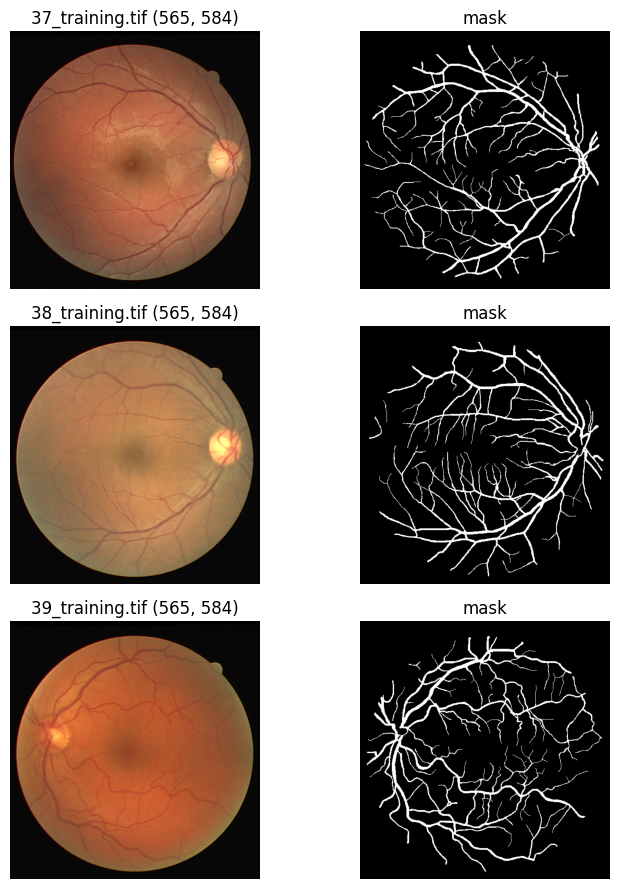

In [18]:
import matplotlib.pyplot as plt

EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.ppm')
test_imgs  = sorted([p for p in glob.glob(f'{TEST_X}/*') if p.lower().endswith(EXTS)])
test_masks = sorted([p for p in glob.glob(f'{TEST_Y}/*') if p.lower().endswith(EXTS)])
print(f'test pairs: imgs={len(test_imgs)}  masks={len(test_masks)}')
for ip, mp in list(zip(test_imgs, test_masks))[:5]:
    print(' ', Path(ip).name, '↔', Path(mp).name)

# Visualise first 3 pairs.
k = min(3, len(test_imgs))
fig, axes = plt.subplots(k, 2, figsize=(8, 3 * k))
for i in range(k):
    img = Image.open(test_imgs[i])
    msk = Image.open(test_masks[i]).convert('L')
    axes[i, 0].imshow(img); axes[i, 0].set_title(f'{Path(test_imgs[i]).name} {img.size}'); axes[i, 0].axis('off')
    axes[i, 1].imshow(msk, cmap='gray'); axes[i, 1].set_title('mask'); axes[i, 1].axis('off')
plt.tight_layout(); plt.show()

## 4. Patch the configs

In [ ]:
import json

TRAIN_CFG = f'{REPO_DIR}/configs/train.yml'
INFER_CFG = f'{REPO_DIR}/configs/inference.yml'

train_cfg = {
    'debug': False, 'mode': 'train', 'cuda': True, 'pin_memory': True,
    'wandb': False, 'worker': 2, 'log_interval': 9999, 'save_interval': 1,
    'saved_model_directory': f'{CKPT_DIR}/{DS_NAME}',
    'train_fold': 1, 'project_name': 'FSG-Net', 'CUDA_VISIBLE_DEVICES': '0',

    'model_name': 'FSGNet_noGRM', 'n_classes': 1, 'in_channels': 3,
    'dataloader': 'Image2Image_zero_pad', 'criterion': 'DiceBCELoss',
    'task': 'segmentation', 'input_space': 'RGB', 'input_channel': 3,
    'input_size': [INPUT_SIZE, INPUT_SIZE],
    'optimizer': 'AdamW', 'lr': 0.001, 'scheduler': 'WarmupCosine',
    'cycles': 100, 'warmup_epoch': 20, 'weight_decay': 0.05,
    'batch_size': 4, 'epoch': 20000, 'ema_decay': 0,
    'class_weight': [1.0, 1.0], 'model_path': '', 'freeze_layer': False,

    'transform_blur': True, 'transform_jitter': True, 'transform_hflip': True,
    'transform_perspective': True, 'transform_cutmix': True,
    'transform_rand_resize': True, 'transform_rand_crop': 288,

    'train_x_path': TRAIN_X, 'train_y_path': TRAIN_Y,
    'val_x_path':   TEST_X,  'val_y_path':   TEST_Y,
}

infer_cfg = {
    'debug': False, 'mode': 'inference', 'cuda': True, 'pin_memory': True,
    'wandb': False, 'worker': 2, 'CUDA_VISIBLE_DEVICES': '0',
    'model_name': 'FSGNet_noGRM', 'n_classes': 1, 'in_channels': 3,
    'inference_mode': 'segmentation', 'task': 'segmentation',
    'dataloader': 'Image2Image_zero_pad', 'criterion': 'DiceBCE',
    'input_space': 'RGB', 'input_channel': 3,
    'input_size': [INPUT_SIZE, INPUT_SIZE],
    'model_path': f'{CKPT_DIR}/FSG-Net-{DATASET}.pt',
    'val_x_path': TEST_X, 'val_y_path': TEST_Y,
}

with open(TRAIN_CFG, 'w') as f: json.dump(train_cfg, f, indent=2)
with open(INFER_CFG, 'w') as f: json.dump(infer_cfg, f, indent=2)
print('Wrote', TRAIN_CFG, '\n      ', INFER_CFG)

## 5. Inference with pretrained weights

Auto-tries the conventional asset URL on the [release page](https://github.com/ZombaSY/FSG-Net-pytorch/releases/tag/1.1.0). If naming differs, manually download into the path the cell prints.

In [ ]:
import urllib.request
ckpt_path = infer_cfg['model_path']
url = f'https://github.com/ZombaSY/FSG-Net-pytorch/releases/download/1.1.0/FSG-Net-{DATASET}.pt'

if not os.path.exists(ckpt_path):
    print('Downloading', url, '→', ckpt_path)
    try:
        urllib.request.urlretrieve(url, ckpt_path)
    except Exception as e:
        print('Auto-download failed:', e)
        print('→ Open the release page manually, save to:', ckpt_path)
else:
    print('Checkpoint already present:', ckpt_path)
if os.path.exists(ckpt_path):
    print('Size (MB):', os.path.getsize(ckpt_path) / 1024**2)

In [ ]:
# 在 cell 4 之后、cell 5 之前插入或追加这个 cell
import glob
my_ckpts = sorted(glob.glob(f'{CKPT_DIR}/{DS_NAME}/*/FSGNet_noGRM-*.pt'))
infer_cfg['model_path'] = my_ckpts[-1]   # 或挑 f1_score 最高的那个文件名
with open(INFER_CFG, 'w') as f: json.dump(infer_cfg, f, indent=2)
print('Inference will use:', infer_cfg['model_path'])


In [21]:
# Should print mIoU / F1 / Acc / AUC / Sensitivity / MCC.
!cd {REPO_DIR} && python3 main.py --config_path configs/inference.yml

Use CUDA : True
Mounting data on memory...Image2ImageLoader_zero_pad:validation
Traceback (most recent call last):
  File "/content/FSG-Net-Baseline/main.py", line 94, in <module>
    main()
  File "/content/FSG-Net-Baseline/main.py", line 83, in main
    inferencer = Inferencer(args)
                 ^^^^^^^^^^^^^^^^
  File "/content/FSG-Net-Baseline/inference.py", line 28, in __init__
    self.model.load_state_dict(torch.load(args.model_path))
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 768, in _open_file_like
    return _open_file(name_or_buffer, mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 749, in __init__
    super().__init__(open(name

### Visualise predictions

`inference.py` saves predictions as `<imgstem>_<idx>_argmax.png` under `<ckpt_dir>/<ckpt_stem>/`.

In [22]:
pred_dir = f'{CKPT_DIR}/FSG-Net-{DATASET}/'
preds = sorted(glob.glob(f'{pred_dir}*_argmax.png'))[:6]
if not preds:
    print('No predictions found at', pred_dir)
else:
    test_img_lookup = {Path(p).stem: p for p in glob.glob(f'{TEST_X}/*')}
    test_msk_lookup = {Path(p).stem: p for p in glob.glob(f'{TEST_Y}/*')}

    fig, axes = plt.subplots(len(preds), 3, figsize=(10, 3 * len(preds)))
    if len(preds) == 1: axes = axes[None, :]
    for i, p in enumerate(preds):
        # 'foo_2_argmax' → 'foo'
        stem = Path(p).stem.replace('_argmax', '')
        stem = '_'.join(stem.split('_')[:-1])
        if stem in test_img_lookup:
            axes[i, 0].imshow(Image.open(test_img_lookup[stem]))
            axes[i, 0].set_title(stem)
        axes[i, 0].axis('off')
        if stem in test_msk_lookup:
            axes[i, 1].imshow(Image.open(test_msk_lookup[stem]).convert('L'), cmap='gray')
            axes[i, 1].set_title('GT')
        axes[i, 1].axis('off')
        axes[i, 2].imshow(Image.open(p), cmap='gray'); axes[i, 2].set_title('pred'); axes[i, 2].axis('off')
    plt.tight_layout(); plt.show()

No predictions found at /content/drive/MyDrive/SegModels/FSGNet/checkpoints/FSG-Net-DRIVE/


## 6. (Optional) Train from scratch / fine-tune

Defaults match the paper (batch 4, AdamW, WarmupCosine, 288² random crop). To fine-tune from a checkpoint, set `train_cfg['model_path']` and re-run the patch cell.

Notes for L4/A100 (Colab Pro):
- DRIVE/STARE/CHASE: defaults fit comfortably.
- HRF: 1344² validation forward pass is heavy. If OOM, drop `input_size` (e.g. `[1024, 1024]`).
- Training crop is 288² regardless of `input_size`; that one only affects validation.

In [ ]:
# Uncomment to train.
!cd {REPO_DIR} && python3 main.py --config_path configs/train.yml

Streaming output truncated to the last 5000 lines.
967 epoch / Val f1_score: 0.8196512372600555
### 967 / 20000 epoch ended###
Start Train
968 epoch / Train Loss DiceBCELoss : 0.40494546890258787, lr 1.089907205484575e-06
968 epoch / Train f1_score: 0.759399990353724
968 epoch / Val f1_score: 0.8206347826398034
### 968 / 20000 epoch ended###
Start Train
969 epoch / Train Loss DiceBCELoss : 0.416372686624527, lr 2.472341277093282e-09
969 epoch / Train f1_score: 0.7569081083601069
969 epoch / Val f1_score: 0.8195113427762368
### 969 / 20000 epoch ended###
Start Train
970 epoch / Train Loss DiceBCELoss : 0.4200183153152466, lr 8.922504399194731e-07
970 epoch / Train f1_score: 0.7348504129918431
970 epoch / Val f1_score: 0.8201424867627953
### 970 / 20000 epoch ended###
Start Train
971 epoch / Train Loss DiceBCELoss : 0.4177093684673309, lr 3.755722922432481e-06
971 epoch / Train f1_score: 0.7552538649088902
971 epoch / Val f1_score: 0.8192185924998017
### 971 / 20000 epoch ended###
Start 